In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit, GroupKFold, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, classification_report, log_loss, brier_score_loss, roc_auc_score,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.chdir("/Users/astitva/Project Basant Panchami")


In [2]:
df = pd.read_csv("data/processed/all_matches_clean.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Shape: (110698, 29)
Columns: ['match_id', 'innings', 'batting_team', 'over', 'runs_per_over', 'intent_runs', 'dot_balls', 'wides', 'noballs', 'wickets', 'fours', 'sixes', 'target', 'winner', 'venue', 'season', 'toss_winner_batting', 'cum_runs', 'wickets_fallen', 'wickets_in_hand', 'crr', 'overs_left', 'rrr', 'crr_vs_rrr', 'phase', 'momentum', 'boundary_rate', 'legal_balls', 'batting_team_won']


In [3]:
FEATURES = [
    "innings",
    "over",
    "cum_runs",
    "wickets_in_hand",
    "crr",
    "rrr",
    "crr_vs_rrr",
    "momentum",
    "boundary_rate",
    "dot_balls",
    "toss_winner_batting",
]

TARGET = "batting_team_won"

X = df[FEATURES]
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")


X shape: (110698, 11)
y shape: (110698,)

y value counts:
batting_team_won
0    57163
1    53535
Name: count, dtype: int64


In [ ]:
# random split was leaking, overs from the same match landing on both
# sides. group by match_id so a whole match stays on one side
groups = df["match_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training rows: {len(X_train)} across {groups.iloc[train_idx].nunique()} matches")
print(f"Testing rows:  {len(X_test)} across {groups.iloc[test_idx].nunique()} matches")

In [5]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print("\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 74.62%

               precision    recall  f1-score   support

           0       0.75      0.77      0.76     11371
           1       0.75      0.72      0.73     10697

    accuracy                           0.75     22068
   macro avg       0.75      0.75      0.75     22068
weighted avg       0.75      0.75      0.75     22068



In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.2%}")
print("\n", classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 74.62%
Random Forest Accuracy:       74.93%

               precision    recall  f1-score   support

           0       0.76      0.74      0.75     11371
           1       0.74      0.75      0.74     10697

    accuracy                           0.75     22068
   macro avg       0.75      0.75      0.75     22068
weighted avg       0.75      0.75      0.75     22068



In [7]:
importance = pd.DataFrame({
    "feature"   : FEATURES,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance)

                feature  importance
0            crr_vs_rrr    0.295490
1                   rrr    0.250675
2                   crr    0.158892
3       wickets_in_hand    0.100421
4              momentum    0.056551
5              cum_runs    0.049207
6               innings    0.038786
7                  over    0.023190
8             dot_balls    0.013830
9         boundary_rate    0.008073
10  toss_winner_batting    0.004885


In [8]:
# Trying deeper trees and more of them
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model_v2.fit(X_train, y_train)
y_pred_v2 = rf_model_v2.predict(X_test)
print(f"Random Forest v1: {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"Random Forest v2: {accuracy_score(y_test, y_pred_v2):.2%}")

Random Forest v1: 74.93%
Random Forest v2: 74.81%


In [9]:
# Splitting test set by innings since innings 1 isnt serving well , isnt very meaningful for predicition
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_pred_rf

inn1 = test_df[test_df["innings"] == 1]
inn2 = test_df[test_df["innings"] == 2]

print(f"1st innings accuracy: {accuracy_score(inn1['actual'], inn1['predicted']):.2%}")
print(f"2nd innings accuracy: {accuracy_score(inn2['actual'], inn2['predicted']):.2%}")

1st innings accuracy: 67.04%
2nd innings accuracy: 83.84%


In [10]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.2%}")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"XGBoost:             {accuracy_score(y_test, y_pred_xgb):.2%}")

Logistic Regression: 74.62%
Random Forest:       74.93%
XGBoost:             74.95%


In [ ]:
# should try hist gradient boosting too before locking in xgboost, sklearn
# already ships it and its basically the same idea as lightgbm
hgb_model = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.08, random_state=42,
)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.2%}")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"XGBoost:             {accuracy_score(y_test, y_pred_xgb):.2%}")
print(f"HistGB:              {accuracy_score(y_test, y_pred_hgb):.2%}")

In [ ]:
# accuracy isnt really the point since the replay needs actual probabilities
# not just win/loss. log loss and brier score punish a confident wrong
# answer so checking those instead
for name, model in [("logreg", lr_model), ("rf", rf_model), ("xgb", xgb_model), ("hgb", hgb_model)]:
    proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:8s} logloss={log_loss(y_test, proba):.4f}  "
          f"brier={brier_score_loss(y_test, proba):.4f}  "
          f"auc={roc_auc_score(y_test, proba):.4f}")

In [ ]:
# single split could just be a lucky/unlucky one, doing 5 fold grouped cv
# on the whole dataset instead so nothing leaks across folds
gkf = GroupKFold(n_splits=5)

cv_candidates = {
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1),
    "hgb": HistGradientBoostingClassifier(max_iter=300, max_depth=6, learning_rate=0.08, random_state=42),
    "xgb": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0),
}

for name, model in cv_candidates.items():
    oof_proba = cross_val_predict(model, X, y, groups=groups, cv=gkf, method="predict_proba", n_jobs=-1)[:, 1]
    print(f"{name:8s} logloss={log_loss(y, oof_proba):.4f}  brier={brier_score_loss(y, oof_proba):.4f}")

In [ ]:
# xgboost edges out hgb by a little, going with that. raw predict_proba
# isnt a real probability tho, so calibrating it - want "70%" to actually
# mean 70%, not just be a good ranking score
calibrated_xgb = CalibratedClassifierCV(clone(xgb_model), method="isotonic", cv=5)
calibrated_xgb.fit(X_train, y_train)

proba_raw = xgb_model.predict_proba(X_test)[:, 1]
proba_cal = calibrated_xgb.predict_proba(X_test)[:, 1]

print(f"raw        logloss={log_loss(y_test, proba_raw):.4f}  brier={brier_score_loss(y_test, proba_raw):.4f}")
print(f"calibrated logloss={log_loss(y_test, proba_cal):.4f}  brier={brier_score_loss(y_test, proba_cal):.4f}")

In [15]:
import joblib

final_model = CalibratedClassifierCV(clone(xgb_model), method="isotonic", cv=5)
final_model.fit(X, y)   # holdout above already checked it generalizes — use everything we've got

joblib.dump({"model": final_model, "features": FEATURES}, "models/win_probability.pkl")
print("XGBoost (calibrated) saved")

loaded = joblib.load("models/win_probability.pkl")
test_pred = loaded["model"].predict(X_test[:5])
print(f"Test predictions: {test_pred}")


XGBoost (calibrated) saved
Test predictions: [0 0 0 0 0]


In [16]:
# Picking one match 
sample_match_id = df["match_id"].iloc[500]
match_data = df[df["match_id"] == sample_match_id].copy()

# Getting win probabilities for every over
match_X = match_data[FEATURES]
match_data["win_prob"] = final_model.predict_proba(match_X)[:, 1]

# Printting the win probabilities
print(f"Match ID: {sample_match_id}")
print(f"Teams: {match_data['batting_team'].unique()}")
print(f"Winner: {match_data['winner'].unique()}")
print(match_data[["innings", "over", "cum_runs", "wickets_in_hand", "win_prob"]].to_string())

Match ID: 1031435
Teams: ['England' 'South Africa']
Winner: ['England']
     innings  over  cum_runs  wickets_in_hand  win_prob
499        1     0         4               10  0.505629
500        1     1        13                9  0.434434
501        1     2        21                9  0.496307
502        1     3        26                9  0.479779
503        1     4        39                9  0.590915
504        1     5        46                9  0.612674
505        1     6        54                9  0.614306
506        1     7        65                9  0.656502
507        1     8        73                9  0.665626
508        1     9        88                9  0.698161
509        1    10        99                9  0.736250
510        1    11       116                9  0.770933
511        1    12       123                8  0.762800
512        1    13       134                7  0.778574
513        1    14       139                7  0.735270
514        1    15       149    

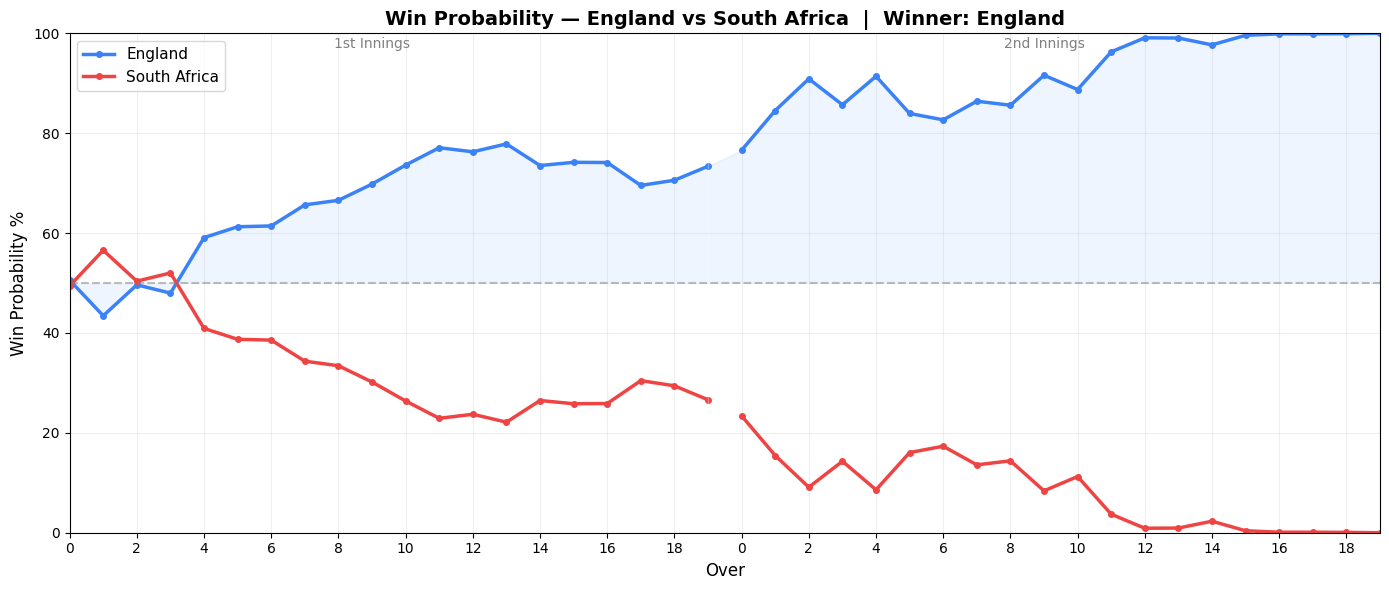

Chart saved ✅


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

inn1 = match_data[match_data["innings"] == 1].copy()
inn2 = match_data[match_data["innings"] == 2].copy()

team1 = inn1["batting_team"].iloc[0]
team2 = inn2["batting_team"].iloc[0]
winner = match_data["winner"].iloc[0]

# Win probabilities as percentages
team1_prob_inn1 = inn1["win_prob"].values * 100
team1_prob_inn2 = (1 - inn2["win_prob"].values) * 100

# X axis — innings 2 shifted by 20
overs_inn1 = inn1["over"].values
overs_inn2 = inn2["over"].values + 20

# Plot team1
ax.plot(overs_inn1, team1_prob_inn1,
        color="#3b82f6", linewidth=2.5, marker="o", markersize=4, label=f"{team1}")
ax.plot(overs_inn2, team1_prob_inn2,
        color="#3b82f6", linewidth=2.5, marker="o", markersize=4)

# Plot team2
ax.plot(overs_inn1, 100 - team1_prob_inn1,
        color="#ef4444", linewidth=2.5, marker="o", markersize=4, label=f"{team2}")
ax.plot(overs_inn2, 100 - team1_prob_inn2,
        color="#ef4444", linewidth=2.5, marker="o", markersize=4)

# 50% line
ax.axhline(50, color="gray", linestyle="--", alpha=0.5)

# Innings divider
ax.axvline(19, color="white", linestyle="-", alpha=0.3, linewidth=1)
ax.text(9,  97, "1st Innings", ha="center", color="gray", fontsize=10)
ax.text(29, 97, "2nd Innings", ha="center", color="gray", fontsize=10)

# Shading
ax.fill_between(
    list(overs_inn1) + list(overs_inn2),
    list(team1_prob_inn1) + list(team1_prob_inn2),
    50, alpha=0.08, color="#3b82f6"
)

# Labels and formatting
ax.set_xlabel("Over", fontsize=12)
ax.set_ylabel("Win Probability %", fontsize=12)
ax.set_ylim(0, 100)
ax.set_xlim(0, 39)
ax.set_xticks(list(range(0, 40, 2)))
ax.set_xticklabels(
    [str(i) for i in range(0, 20, 2)] + [str(i) for i in range(0, 20, 2)]
)
ax.set_title(
    f"Win Probability — {team1} vs {team2}  |  Winner: {winner}",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("win_probability_chart.png", dpi=150)
plt.show()
print("Chart saved ✅")